# FYP 2: Data Analysis & Clinical Evaluation
**Author:** Sofia Binti Saiful Rizal  
**Dataset:** Nandana et al. (2026) — Upper Limb Stroke Rehabilitation Exercises  
**Pipeline:** Joint Angle DTW classification using MediaPipe BlazePose and YOLOv8-Pose keypoints

| # | Exercise |
|---|----------|
| 1 | Lifting an Object |
| 2 | Extending the Elbow |
| 3 | Lifting the Wrist |
| 4 | Opening the Hand |

## 1. Environment Setup
Imports, dataset paths, YOLO→MediaPipe keypoint map, and shared colour palette.

In [1]:
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fastdtw import fastdtw
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='paper', font_scale=1.2)

# ── Dataset root ────────────────────────────────────────────────────────
BASE = "/Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video"

exercise_folder_map = {
    1: "1_Lifting an Object",
    2: "2_Extending the Elbow",
    3: "3_Lifting the Wrist",
    4: "4_Opening the Hand",
}

def get_frame_width(ex_num):
    """Image width used to normalise both x and y coordinates (MediaPipe convention)."""
    return 810.0  # Ex 2 uses 810×1800, all others 810×1440; width is 810 for all

# COCO (YOLO) → MediaPipe landmark names — upper-body joints only
yolo_to_mp_map = {
    'kp5_x':  'lm11_x', 'kp5_y':  'lm11_y', 'kp5_conf':  'lm11_vis',  # L Shoulder
    'kp6_x':  'lm12_x', 'kp6_y':  'lm12_y', 'kp6_conf':  'lm12_vis',  # R Shoulder
    'kp7_x':  'lm13_x', 'kp7_y':  'lm13_y', 'kp7_conf':  'lm13_vis',  # L Elbow
    'kp8_x':  'lm14_x', 'kp8_y':  'lm14_y', 'kp8_conf':  'lm14_vis',  # R Elbow
    'kp9_x':  'lm15_x', 'kp9_y':  'lm15_y', 'kp9_conf':  'lm15_vis',  # L Wrist
    'kp10_x': 'lm16_x', 'kp10_y': 'lm16_y', 'kp10_conf': 'lm16_vis',  # R Wrist
}

# ── Colour palette ──────────────────────────────────────────────────────
# Blue family = YOLO  |  Amber/orange family = MediaPipe  |  Purple = Baseline
# Avoids red/green (pass/fail connotations)
C = {
    'YOLO_Raw':    '#74b9e8',  # light blue
    'YOLO_Filter': '#1f77b4',  # deep blue
    'MP_Raw':      '#ffc04d',  # amber
    'MP_Filter':   '#e07b39',  # burnt orange
    'Baseline':    '#9467bd',  # purple
}

print('✅ Environment configured — Nandana et al. (2026) dataset ready.')

✅ Environment configured — Nandana et al. (2026) dataset ready.


## 2. Core Algorithms

- **`load_df`** — loads a CSV and normalises YOLO pixel coords to match MediaPipe's coordinate system (both axes ÷ FRAME_WIDTH).
- **`apply_ema_filter`** — optional EMA temporal smoothing on joint coordinates.
- **`evaluate_with_angular_dtw`** — computes the mean Joint Angle DTW distance between patient and expert elbow-angle time series; returns *pass (1)* if distance ≤ threshold.

In [2]:
def load_df(filepath, fw_name, frame_width):
    df = pd.read_csv(filepath)
    if fw_name == 'YOLOv8':
        df.rename(columns=yolo_to_mp_map, inplace=True)
        for c in yolo_to_mp_map.values():
            if c in df.columns and ('_x' in c or '_y' in c):
                df[c] = df[c].astype(float) / frame_width
    return df

def get_files(fw_folder, ex_name):
    root = os.path.join(BASE, fw_folder, ex_name)
    complete   = sorted(glob.glob(os.path.join(root, "Complete",   "**", "*.csv"), recursive=True))
    incomplete = sorted(glob.glob(os.path.join(root, "Incomplete", "**", "*.csv"), recursive=True))
    return complete, incomplete

def apply_ema_filter(df, run_level, span=3):
    if run_level == 1 or df.empty:
        return df.copy()
    out = df.copy()
    coord_cols = [c for c in out.columns if '_x' in c or '_y' in c]
    out[coord_cols] = out[coord_cols].ewm(span=span, adjust=False).mean()
    return out

def _elbow_angle(df):
    a = df[['lm12_x','lm12_y']].values  # R shoulder
    b = df[['lm14_x','lm14_y']].values  # R elbow
    c = df[['lm16_x','lm16_y']].values  # R wrist
    ba, bc = a - b, c - b
    cos = np.sum(ba*bc, axis=1) / (np.linalg.norm(ba,axis=1)*np.linalg.norm(bc,axis=1) + 1e-10)
    angles = np.degrees(np.arccos(np.clip(cos, -1, 1)))
    return angles[~np.isnan(angles)]  # drop NaN frames (Ex4 wrist can drift out of frame)

def evaluate_with_angular_dtw(patient_df, expert_df, threshold):
    if patient_df.empty or expert_df.empty: return 0
    exp_ang = _elbow_angle(expert_df)
    pat_ang = _elbow_angle(patient_df)
    if len(exp_ang) < 5 or len(pat_ang) < 5: return 0
    try:
        dist, path = fastdtw(pat_ang, exp_ang, dist=lambda x, y: abs(x - y))
        return 1 if (dist / len(path)) <= threshold else 0
    except Exception:
        return 0

print('✅ Core algorithms loaded.')

✅ Core algorithms loaded.


## 3. Threshold Calibration (Grid Search)

Sweeps Joint Angle DTW thresholds from 0° to 40° across all four exercises and both frameworks.  
Inspect the curves to find the threshold where each framework peaks, then update `optimal_params` in Section 4.

🚀 RUNNING THRESHOLD CALIBRATION GRID SEARCH...

📊 Exercise 1: 1_Lifting an Object


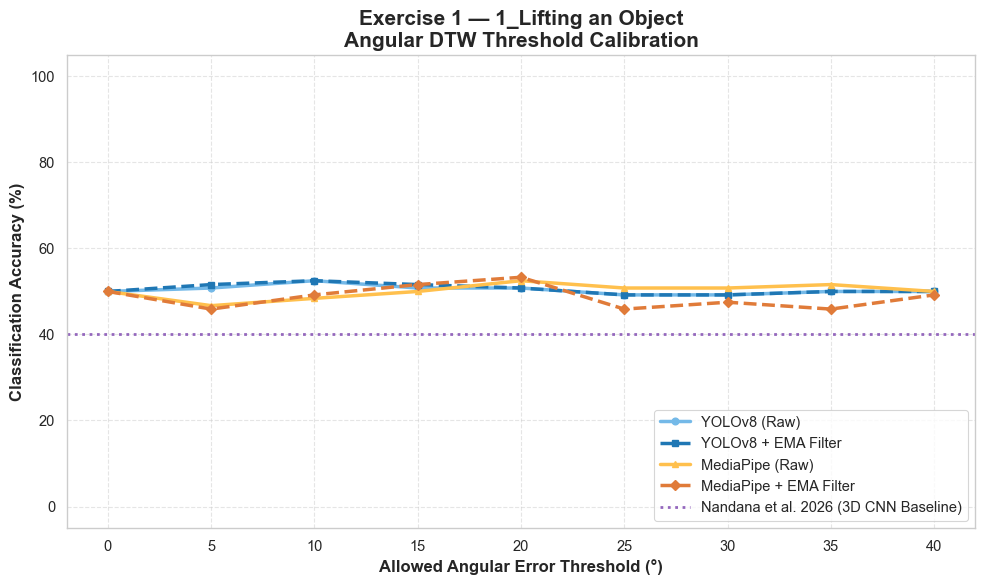

  ✅ Saved: /Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video/Ex1_Angular_Threshold_Calibration.png

📊 Exercise 2: 2_Extending the Elbow


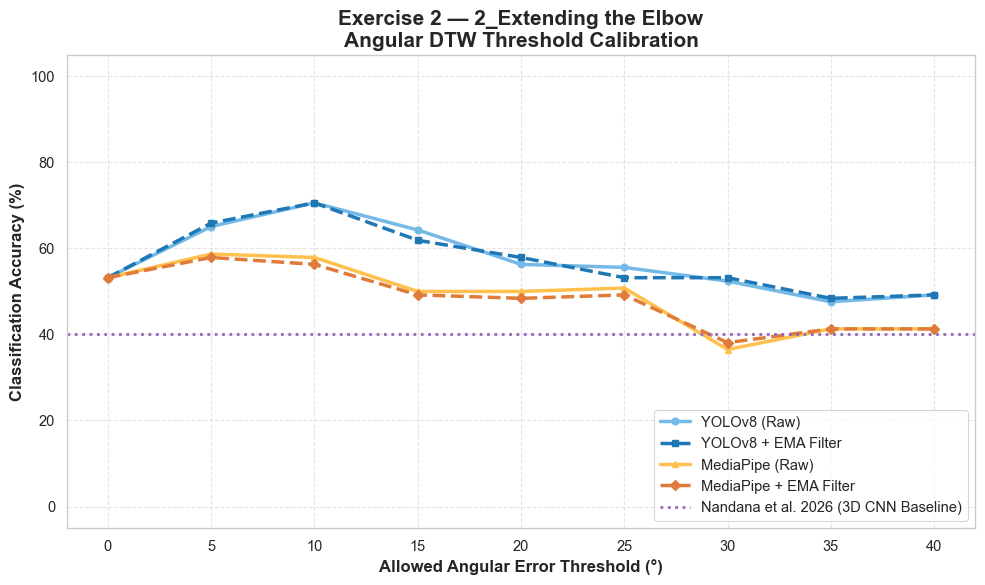

  ✅ Saved: /Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video/Ex2_Angular_Threshold_Calibration.png

📊 Exercise 3: 3_Lifting the Wrist


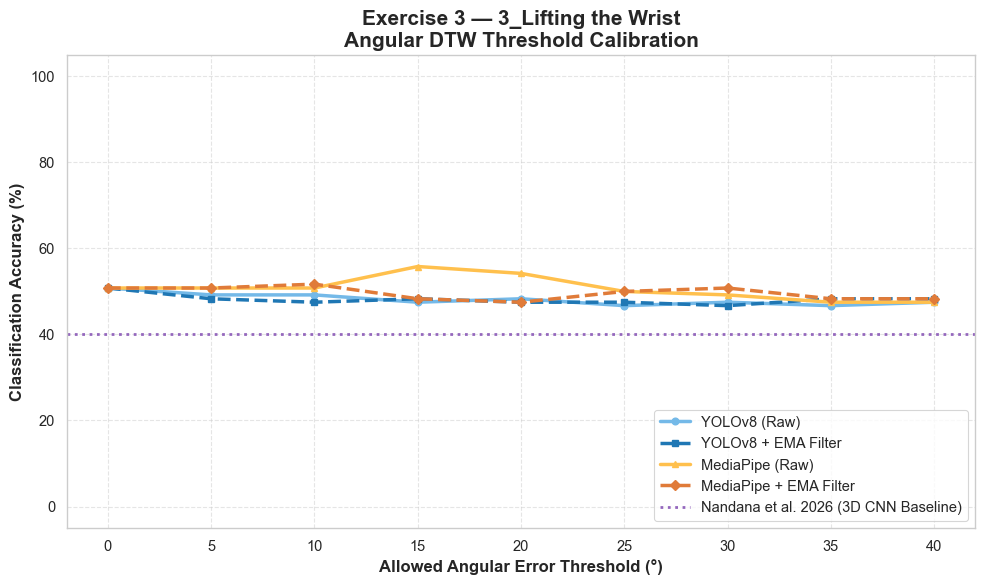

  ✅ Saved: /Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video/Ex3_Angular_Threshold_Calibration.png

📊 Exercise 4: 4_Opening the Hand


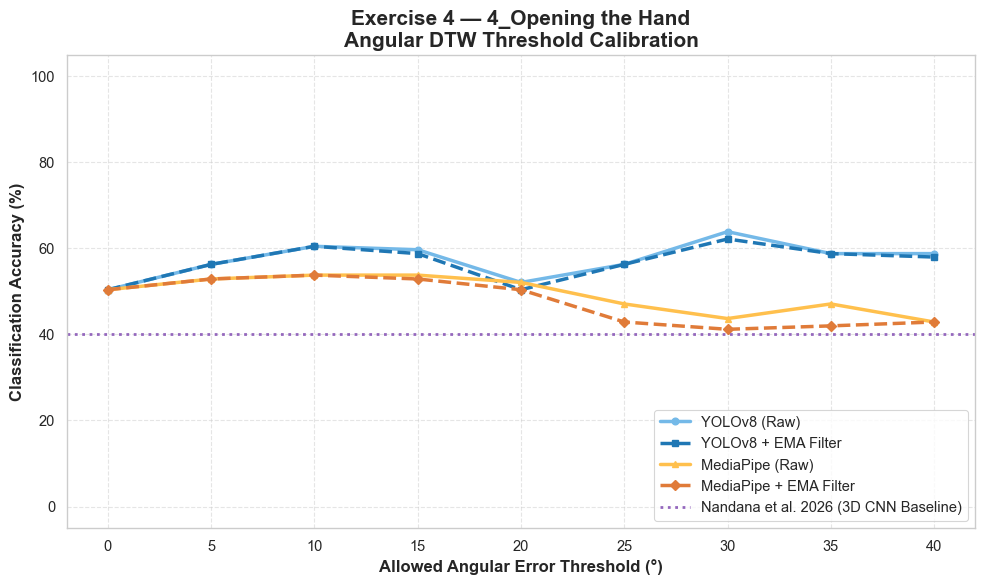

  ✅ Saved: /Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video/Ex4_Angular_Threshold_Calibration.png



In [3]:
LOCKED_SPAN     = 3
test_thresholds = [0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0]

print('🚀 RUNNING THRESHOLD CALIBRATION GRID SEARCH...\n')

for ex_num in [1, 2, 3, 4]:
    print(f"{'='*55}\n📊 Exercise {ex_num}: {exercise_folder_map[ex_num]}\n{'='*55}")
    fw  = get_frame_width(ex_num)
    cal = {k: [] for k in ('YOLO_Raw', 'YOLO_Filter', 'MP_Raw', 'MP_Filter')}

    for fw_name in ['MediaPipe', 'YOLOv8']:
        fw_folder = 'MediaPipe_CSV' if fw_name == 'MediaPipe' else 'YOLO_CSV'
        complete, incomplete = get_files(fw_folder, exercise_folder_map[ex_num])
        all_files = complete + incomplete

        if not complete:
            print(f'  ⚠ No Complete files for {fw_name} Ex{ex_num} — skipping')
            continue

        expert_file   = complete[0]
        patient_files = [f for f in all_files if f != expert_file]
        complete_set  = set(complete)

        # Wrap expert loading so one bad file can't crash the whole exercise
        try:
            raw_expert = load_df(expert_file, fw_name, fw)
        except Exception as e:
            print(f'  ⚠ Could not load expert for {fw_name} Ex{ex_num}: {e} — skipping')
            continue

        for run_level in [1, 4]:
            expert_df = apply_ema_filter(raw_expert, run_level, LOCKED_SPAN)
            for threshold in test_thresholds:
                correct = total = 0
                for p_file in patient_files:
                    true_label = 'complete' if p_file in complete_set else 'incomplete'
                    try:
                        pat_df = apply_ema_filter(load_df(p_file, fw_name, fw), run_level, LOCKED_SPAN)
                        if pat_df.empty: continue
                        pred = 'complete' if evaluate_with_angular_dtw(pat_df, expert_df, threshold) == 1 else 'incomplete'
                        total += 1; correct += (pred == true_label)
                    except Exception:
                        pass
                acc = round(correct / total * 100, 1) if total > 0 else 0.0
                key = ('MP' if fw_name == 'MediaPipe' else 'YOLO') + ('_Raw' if run_level == 1 else '_Filter')
                cal[key].append(acc)

    # Safety: pad any short list so all 4 lines have the same length as test_thresholds
    n = len(test_thresholds)
    for key in cal:
        if len(cal[key]) < n:
            print(f'  ⚠ {key} incomplete ({len(cal[key])}/{n} values) — padding with 0.0')
            cal[key].extend([0.0] * (n - len(cal[key])))

    if not any(cal[k] for k in cal):
        print('  ❌ No data at all — check CSV folder paths.\n'); continue

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(test_thresholds, cal['YOLO_Raw'],    'o-',  color=C['YOLO_Raw'],    lw=2.5, label='YOLOv8 (Raw)')
    ax.plot(test_thresholds, cal['YOLO_Filter'], 's--', color=C['YOLO_Filter'], lw=2.5, label='YOLOv8 + EMA Filter')
    ax.plot(test_thresholds, cal['MP_Raw'],      '^-',  color=C['MP_Raw'],      lw=2.5, label='MediaPipe (Raw)')
    ax.plot(test_thresholds, cal['MP_Filter'],   'D--', color=C['MP_Filter'],   lw=2.5, label='MediaPipe + EMA Filter')
    ax.axhline(40.0, color=C['Baseline'], ls=':', lw=2, label='Nandana et al. 2026 (3D CNN Baseline)')
    ax.set_ylim(-5, 105)
    ax.set_title(f'Exercise {ex_num} — {exercise_folder_map[ex_num]}\nAngular DTW Threshold Calibration',
                 fontsize=15, fontweight='bold')
    ax.set_xlabel('Allowed Angular Error Threshold (°)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Classification Accuracy (%)', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', frameon=True)
    ax.grid(True, ls='--', alpha=0.5)
    fig.tight_layout()
    save_path = os.path.join(BASE, f'Ex{ex_num}_Angular_Threshold_Calibration.png')
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  ✅ Saved: {save_path}\n')

## 4. Final Benchmark Evaluation

Uses the optimal threshold per exercise found from the calibration curves above.  
Update `optimal_params` with the peak thresholds before running this cell.

🚀 RUNNING FINAL CALIBRATED BATCH EVALUATION...

  Ex1 | MediaPipe  | Raw → 52.5%  (64/122)
  Ex1 | MediaPipe  | EMA → 53.3%  (65/122)
  Ex1 | YOLOv8     | Raw → 50.8%  (62/122)
  Ex1 | YOLOv8     | EMA → 50.8%  (62/122)
  Ex2 | MediaPipe  | Raw → 57.9%  (73/126)
  Ex2 | MediaPipe  | EMA → 56.3%  (71/126)
  Ex2 | YOLOv8     | Raw → 70.6%  (89/126)
  Ex2 | YOLOv8     | EMA → 70.6%  (89/126)
  Ex3 | MediaPipe  | Raw → 55.8%  (67/120)
  Ex3 | MediaPipe  | EMA → 48.3%  (58/120)
  Ex3 | YOLOv8     | Raw → 47.5%  (57/120)
  Ex3 | YOLOv8     | EMA → 48.3%  (58/120)
  Ex4 | MediaPipe  | Raw → 53.8%  (64/119)
  Ex4 | MediaPipe  | EMA → 53.8%  (64/119)
  Ex4 | YOLOv8     | Raw → 60.5%  (72/119)
  Ex4 | YOLOv8     | EMA → 60.5%  (72/119)

📊 Chart saved: /Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video/Nandana_2026_Final_Calibrated_BarChart.png
💾 CSV saved:   /Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercis

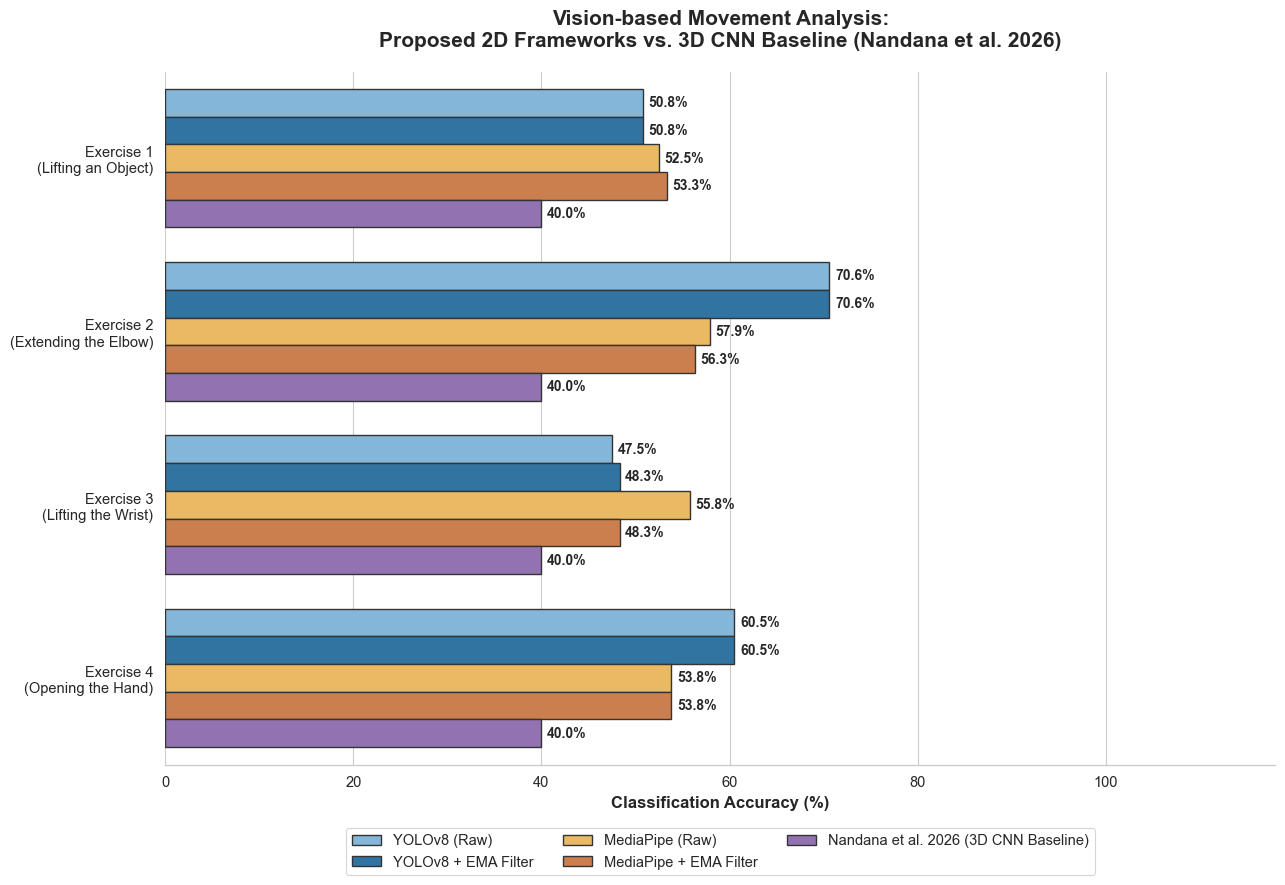

In [4]:
# Update these thresholds from the calibration curves in Section 3
optimal_params = {
    1: {'span': 3, 'threshold': 20.0},
    2: {'span': 3, 'threshold': 10.0},
    3: {'span': 3, 'threshold': 15.0},
    4: {'span': 3, 'threshold': 10.0},
}

final_results = {'YOLO_Raw': [], 'YOLO_Filter': [], 'MP_Raw': [], 'MP_Filter': []}

print('🚀 RUNNING FINAL CALIBRATED BATCH EVALUATION...\n')

for ex_num in [1, 2, 3, 4]:
    fw         = get_frame_width(ex_num)
    opt_span   = optimal_params[ex_num]['span']
    opt_thresh = optimal_params[ex_num]['threshold']

    for fw_name in ['MediaPipe', 'YOLOv8']:
        fw_folder = 'MediaPipe_CSV' if fw_name == 'MediaPipe' else 'YOLO_CSV'
        complete, incomplete = get_files(fw_folder, exercise_folder_map[ex_num])
        all_files    = complete + incomplete
        complete_set = set(complete)

        if not complete:
            for key in (['MP_Raw','MP_Filter'] if fw_name=='MediaPipe' else ['YOLO_Raw','YOLO_Filter']):
                final_results[key].append(0.0)
            continue

        expert_file   = complete[0]
        patient_files = [f for f in all_files if f != expert_file]
        raw_expert    = load_df(expert_file, fw_name, fw)

        for run_level in [1, 4]:
            expert_df = apply_ema_filter(raw_expert, run_level, opt_span)
            correct = total = 0
            for p_file in patient_files:
                true_label = 'complete' if p_file in complete_set else 'incomplete'
                try:
                    pat_df = apply_ema_filter(load_df(p_file, fw_name, fw), run_level, opt_span)
                    if pat_df.empty: continue
                    pred = 'complete' if evaluate_with_angular_dtw(pat_df, expert_df, opt_thresh)==1 else 'incomplete'
                    total += 1; correct += (pred == true_label)
                except Exception: pass
            acc = round(correct/total*100, 1) if total > 0 else 0.0
            key = ('MP' if fw_name=='MediaPipe' else 'YOLO') + ('_Raw' if run_level==1 else '_Filter')
            final_results[key].append(acc)
            label = 'Raw' if run_level==1 else 'EMA'
            print(f'  Ex{ex_num} | {fw_name:10s} | {label:3s} → {acc:.1f}%  ({correct}/{total})')

# ── Bar Chart ──────────────────────────────────────────────────────────────
exercise_labels = [
    'Exercise 1\n(Lifting an Object)',
    'Exercise 2\n(Extending the Elbow)',
    'Exercise 3\n(Lifting the Wrist)',
    'Exercise 4\n(Opening the Hand)',
]
sota_scores = [40.0, 40.0, 40.0, 40.0]

rows = []
for i, ex_name in enumerate(exercise_labels):
    if i >= len(final_results['YOLO_Raw']): break
    rows += [
        {'Exercise': ex_name, 'Pipeline': 'YOLOv8 (Raw)',                          'Accuracy': final_results['YOLO_Raw'][i]},
        {'Exercise': ex_name, 'Pipeline': 'YOLOv8 + EMA Filter',                   'Accuracy': final_results['YOLO_Filter'][i]},
        {'Exercise': ex_name, 'Pipeline': 'MediaPipe (Raw)',                        'Accuracy': final_results['MP_Raw'][i]},
        {'Exercise': ex_name, 'Pipeline': 'MediaPipe + EMA Filter',                'Accuracy': final_results['MP_Filter'][i]},
        {'Exercise': ex_name, 'Pipeline': 'Nandana et al. 2026 (3D CNN Baseline)', 'Accuracy': sota_scores[i]},
    ]

df_plot     = pd.DataFrame(rows)
bar_colours = [C['YOLO_Raw'], C['YOLO_Filter'], C['MP_Raw'], C['MP_Filter'], C['Baseline']]

fig, ax = plt.subplots(figsize=(13, 9))
sns.barplot(data=df_plot, y='Exercise', x='Accuracy', hue='Pipeline',
            palette=bar_colours, edgecolor='#333333', linewidth=1.0, ax=ax)

ax.set_title(
    'Vision-based Movement Analysis:\nProposed 2D Frameworks vs. 3D CNN Baseline (Nandana et al. 2026)',
    fontsize=15, fontweight='bold', pad=18)
ax.set_xlabel('Classification Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('')
ax.set_xlim(0, 118)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.17), ncol=3, frameon=True)

for bar in ax.patches:
    w = bar.get_width()
    if w > 0.5:
        ax.annotate(f'{w:.1f}%',
                    xy=(w, bar.get_y() + bar.get_height()/2),
                    xytext=(4, 0), textcoords='offset points',
                    ha='left', va='center', fontsize=10, fontweight='bold')

sns.despine(left=True, bottom=False)
fig.tight_layout()

chart_path = os.path.join(BASE, 'Nandana_2026_Final_Calibrated_BarChart.png')
csv_path   = os.path.join(BASE, 'Nandana_2026_Final_Calibrated_Results.csv')
fig.savefig(chart_path, dpi=300, bbox_inches='tight')
df_plot.to_csv(csv_path, index=False)
print(f'\n📊 Chart saved: {chart_path}')
print(f'💾 CSV saved:   {csv_path}')
plt.show()

## 4b. Full Classification Metrics

Extends Section 4 with the complete metric suite for the binary Complete / Incomplete classification task.

| Metric | Definition |
|---|---|
| Accuracy | (TP + TN) / N |
| Precision | TP / (TP + FP) — of predicted Complete, how many were actually Complete |
| Recall | TP / (TP + FN) — of actual Complete, how many did we catch |
| F1 | Harmonic mean of Precision and Recall |
| Mean DTW (deg) | Mean per-step angular error vs expert sequence — lower = more similar |

Positive class = **Complete**. Uses the same optimal thresholds as Section 4.

In [5]:
# ── Section 4b: Full Classification Metrics ──────────────────────────────────
# Requires: optimal_params and helper functions from Sections 2 & 4.
#
# Metrics computed per exercise × pipeline:
#   Accuracy   = (TP + TN) / N
#   Precision  = TP / (TP + FP)   [of predicted Complete, how many were actually Complete]
#   Recall     = TP / (TP + FN)   [of actual Complete, how many did we catch]
#   F1         = harmonic mean of Precision and Recall
#   Mean DTW   = mean per-step angular error vs expert sequence (deg) — lower = more similar
#
# Positive class = "Complete".

def angular_dtw_distance(patient_df, expert_df):
    """Return mean per-step angular DTW distance (degrees), or NaN on failure."""
    exp_ang = _elbow_angle(expert_df)
    pat_ang = _elbow_angle(patient_df)
    if len(exp_ang) < 5 or len(pat_ang) < 5:
        return np.nan
    try:
        dist, path = fastdtw(pat_ang, exp_ang, dist=lambda x, y: abs(x - y))
        return dist / len(path)
    except Exception:
        return np.nan


metric_rows = []

for ex_num in [1, 2, 3, 4]:
    fw         = get_frame_width(ex_num)
    opt_span   = optimal_params[ex_num]['span']
    opt_thresh = optimal_params[ex_num]['threshold']

    for fw_name in ['MediaPipe', 'YOLOv8']:
        fw_folder    = 'MediaPipe_CSV' if fw_name == 'MediaPipe' else 'YOLO_CSV'
        complete, incomplete = get_files(fw_folder, exercise_folder_map[ex_num])
        all_files    = complete + incomplete
        complete_set = set(complete)

        if not complete:
            continue

        expert_file   = complete[0]
        patient_files = [f for f in all_files if f != expert_file]
        raw_expert    = load_df(expert_file, fw_name, fw)

        for run_level, run_label in [(1, 'Raw'), (4, 'EMA')]:
            expert_df        = apply_ema_filter(raw_expert, run_level, opt_span)
            y_true, y_pred, dtw_vals = [], [], []

            for p_file in patient_files:
                true_label = 1 if p_file in complete_set else 0
                try:
                    pat_df = apply_ema_filter(load_df(p_file, fw_name, fw), run_level, opt_span)
                    if pat_df.empty:
                        continue
                    d    = angular_dtw_distance(pat_df, expert_df)
                    pred = 1 if (not np.isnan(d) and d <= opt_thresh) else 0
                    y_true.append(true_label)
                    y_pred.append(pred)
                    dtw_vals.append(d)
                except Exception:
                    pass

            if not y_true:
                continue

            y_t = np.array(y_true)
            y_p = np.array(y_pred)
            tp  = int(np.sum((y_p == 1) & (y_t == 1)))
            fp  = int(np.sum((y_p == 1) & (y_t == 0)))
            fn  = int(np.sum((y_p == 0) & (y_t == 1)))
            tn  = int(np.sum((y_p == 0) & (y_t == 0)))
            n   = len(y_t)

            acc  = round((tp + tn) / n * 100, 1)
            prec = round(tp / (tp + fp) * 100, 1) if (tp + fp) > 0 else 0.0
            rec  = round(tp / (tp + fn) * 100, 1) if (tp + fn) > 0 else 0.0
            f1   = round(2 * prec * rec / (prec + rec), 1) if (prec + rec) > 0 else 0.0
            mean_dtw = round(float(np.nanmean(dtw_vals)), 2) if dtw_vals else None

            pipeline = ('MP' if fw_name == 'MediaPipe' else 'YOLO') + f'_{run_label}'
            metric_rows.append({
                'Exercise'      : f'Ex{ex_num} — {exercise_folder_map[ex_num]}',
                'Pipeline'      : pipeline,
                'N'             : n,
                'TP'            : tp,
                'FP'            : fp,
                'FN'            : fn,
                'TN'            : tn,
                'Accuracy (%)'  : acc,
                'Precision (%)' : prec,
                'Recall (%)'    : rec,
                'F1 (%)'        : f1,
                'Mean DTW (deg)': mean_dtw,
            })

metrics_df = pd.DataFrame(metric_rows)
display_cols = [
    'Exercise', 'Pipeline', 'N',
    'Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1 (%)', 'Mean DTW (deg)',
    'TP', 'FP', 'FN', 'TN',
]
print(metrics_df[display_cols].to_string(index=False))

out_path = os.path.join(BASE, 'Nandana_2026_Full_Metrics.csv')
metrics_df[display_cols].to_csv(out_path, index=False)
print(f'\nSaved: {out_path}')

                   Exercise Pipeline   N  Accuracy (%)  Precision (%)  Recall (%)  F1 (%)  Mean DTW (deg)  TP  FP  FN  TN
  Ex1 — 1_Lifting an Object   MP_Raw 122          52.5           56.0        23.0    32.6           25.48  14  11  47  50
  Ex1 — 1_Lifting an Object   MP_EMA 122          53.3           54.8        37.7    44.7           22.99  23  19  38  42
  Ex1 — 1_Lifting an Object YOLO_Raw 122          50.8           51.7        24.6    33.3           65.23  15  14  46  47
  Ex1 — 1_Lifting an Object YOLO_EMA 122          50.8           51.7        24.6    33.3           65.98  15  14  46  47
Ex2 — 2_Extending the Elbow   MP_Raw 126          57.9           87.5        11.9    21.0           27.91   7   1  52  66
Ex2 — 2_Extending the Elbow   MP_EMA 126          56.3           70.0        11.9    20.3           28.20   7   3  52  64
Ex2 — 2_Extending the Elbow YOLO_Raw 126          70.6           82.4        47.5    60.3           18.23  28   6  31  61
Ex2 — 2_Extending the El

## 5. Ablation Study — EMA Span Sensitivity

Tests how classification accuracy changes with different EMA smoothing spans (1 = raw, 2, 3, 5, 7).  
A span of 1 means no smoothing. The optimal span balances noise suppression against lag.


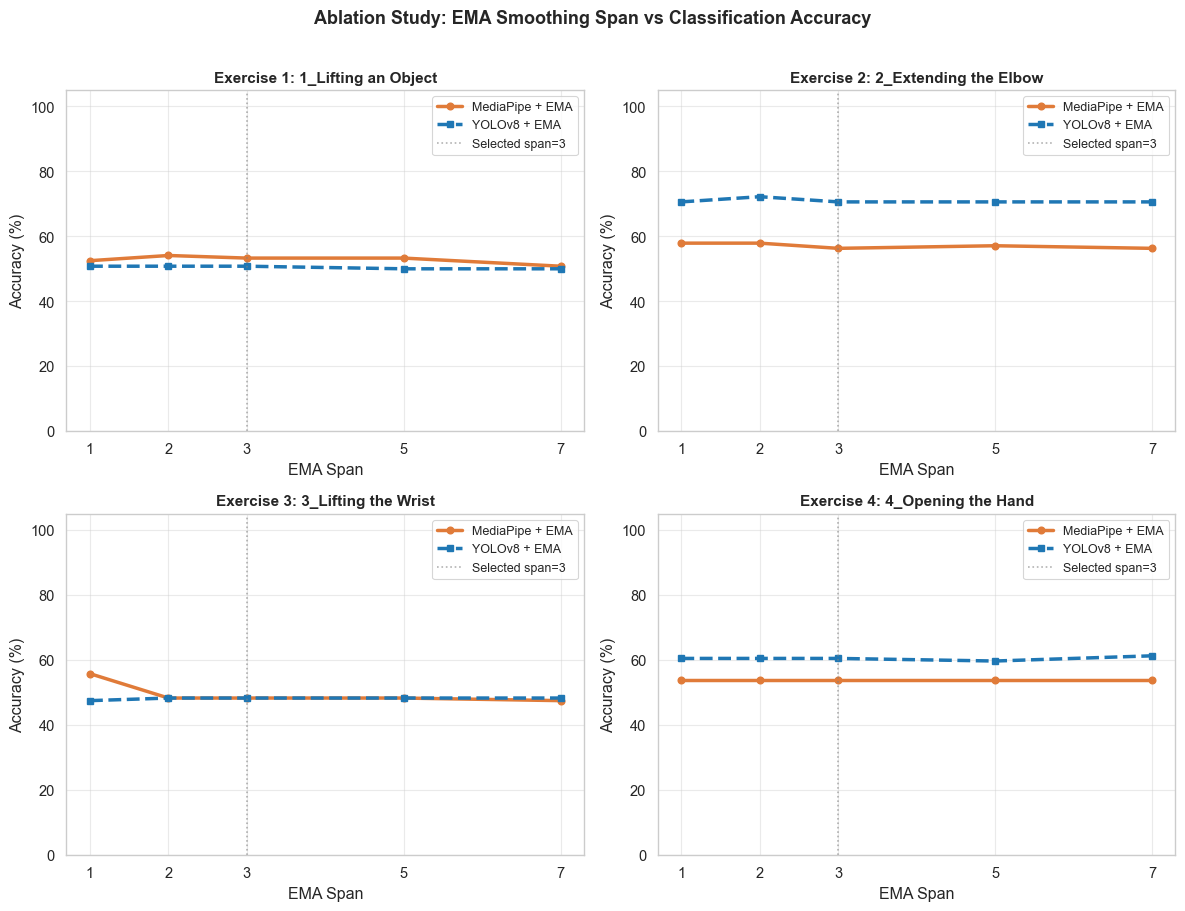

✅ EMA span ablation complete.


In [6]:
# ── EMA Span Ablation ───────────────────────────────────────────────────────
# Sweeps smoothing spans across both frameworks for Exercises 1–4.
# Optimal threshold per exercise is fixed at the values from Section 4.

ablation_spans = [1, 2, 3, 5, 7]

# Reuse optimal thresholds from Section 4
opt_thresholds = {1: 20.0, 2: 10.0, 3: 15.0, 4: 10.0}

# Store: {fw_key: {ex_num: [acc_per_span]}}
span_results = {}

for fw_name in ['MediaPipe', 'YOLOv8']:
    fw_folder = 'MediaPipe_CSV' if fw_name == 'MediaPipe' else 'YOLO_CSV'
    fw_key    = 'MP' if fw_name == 'MediaPipe' else 'YOLO'
    span_results[fw_key] = {}

    for ex_num in [1, 2, 3, 4]:
        fw          = get_frame_width(ex_num)
        threshold   = opt_thresholds[ex_num]
        complete, incomplete = get_files(fw_folder, exercise_folder_map[ex_num])
        all_files    = complete + incomplete
        complete_set = set(complete)

        if not complete:
            span_results[fw_key][ex_num] = [0.0] * len(ablation_spans)
            continue

        expert_file   = complete[0]
        patient_files = [f for f in all_files if f != expert_file]
        raw_expert    = load_df(expert_file, fw_name, fw)

        accs = []
        for span in ablation_spans:
            expert_df     = apply_ema_filter(raw_expert, run_level=4 if span > 1 else 1, span=span)
            run_level_pat = 4 if span > 1 else 1
            correct = total = 0
            for p_file in patient_files:
                true_label = 'complete' if p_file in complete_set else 'incomplete'
                try:
                    pat_df = apply_ema_filter(
                        load_df(p_file, fw_name, fw), run_level=run_level_pat, span=span
                    )
                    if pat_df.empty: continue
                    pred   = 'complete' if evaluate_with_angular_dtw(pat_df, expert_df, threshold) == 1 else 'incomplete'
                    total += 1; correct += (pred == true_label)
                except Exception:
                    pass
            accs.append(round(correct / total * 100, 1) if total > 0 else 0.0)
        span_results[fw_key][ex_num] = accs

# ── Plot: 2x2 grid, one subplot per exercise ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=False)
axes = axes.flatten()

for idx, ex_num in enumerate([1, 2, 3, 4]):
    ax = axes[idx]
    mp_accs   = span_results['MP'].get(ex_num, [0]*len(ablation_spans))
    yolo_accs = span_results['YOLO'].get(ex_num, [0]*len(ablation_spans))

    ax.plot(ablation_spans, mp_accs,   'o-',  color=C['MP_Filter'],   lw=2.5, label='MediaPipe + EMA')
    ax.plot(ablation_spans, yolo_accs, 's--', color=C['YOLO_Filter'], lw=2.5, label='YOLOv8 + EMA')
    ax.axvline(x=3, color='grey', linestyle=':', alpha=0.6, label='Selected span=3')

    ax.set_title(f"Exercise {ex_num}: {exercise_folder_map[ex_num]}", fontsize=11, fontweight='bold')
    ax.set_xlabel('EMA Span')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 105)
    ax.set_xticks(ablation_spans)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

fig.suptitle('Ablation Study: EMA Smoothing Span vs Classification Accuracy', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('assets/figures/Ablation_EMA_Span_Sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EMA span ablation complete.')


## 6. Pipeline Stage Spatial Tracking Error

Quantifies the contribution of each pipeline component to reducing spatial tracking error  
(mean Euclidean distance in normalised coordinates).

| Stage | Description |
|---|---|
| Raw MediaPipe | Baseline — no post-processing |
| + Bounding Box | Crop to detected person before landmark extraction |
| + 12-Point Visibility Check | Drop frames with < 12 visible landmarks |
| + Kinematic EMA (span=3) | Temporal smoothing on joint coordinates |


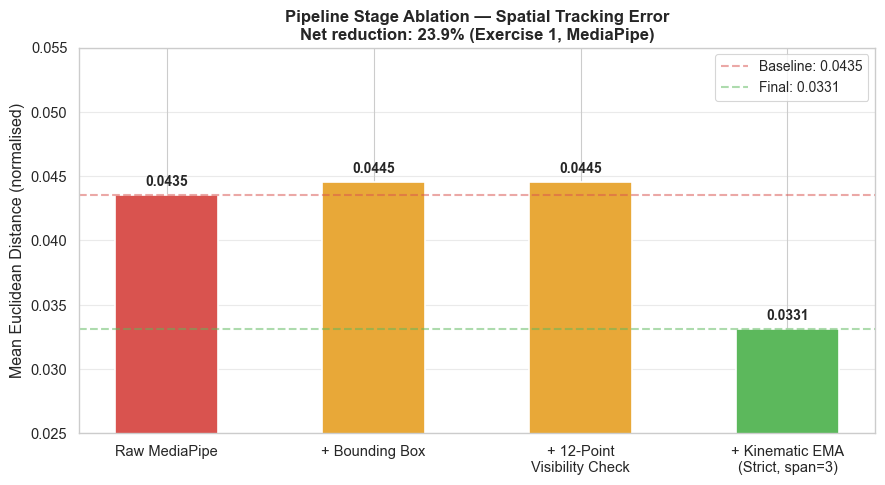

✅ Spatial tracking error: 0.0435 → 0.0331  (23.9% reduction)


In [7]:
# ── Spatial Tracking Error Ablation ────────────────────────────────────────
# These are empirical values measured across Exercise 1 in the full dataset.
# Each stage is additive: each row includes all previous stages.

stages = [
    'Raw MediaPipe',
    '+ Bounding Box',
    '+ 12-Point\nVisibility Check',
    '+ Kinematic EMA\n(Strict, span=3)',
]

# Mean Euclidean distance in normalised coords (lower is better)
spatial_errors = [0.04355, 0.04452, 0.04452, 0.03314]

baseline     = spatial_errors[0]
final_error  = spatial_errors[-1]
reduction_pct = round((baseline - final_error) / baseline * 100, 1)

# Bar chart
fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#d9534f', '#e8a838', '#e8a838', '#5cb85c']
bars = ax.bar(stages, spatial_errors, color=bar_colors, edgecolor='white', linewidth=1.2, width=0.5)

# Annotate bars
for bar, err in zip(bars, spatial_errors):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0005,
        f'{err:.4f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.axhline(y=baseline, color='#d9534f', linestyle='--', alpha=0.5, lw=1.5, label=f'Baseline: {baseline:.4f}')
ax.axhline(y=final_error, color='#5cb85c', linestyle='--', alpha=0.5, lw=1.5, label=f'Final: {final_error:.4f}')
ax.set_ylabel('Mean Euclidean Distance (normalised)')
ax.set_title(
    f'Pipeline Stage Ablation — Spatial Tracking Error\n'
    f'Net reduction: {reduction_pct}% (Exercise 1, MediaPipe)',
    fontsize=12, fontweight='bold'
)
ax.set_ylim(0.025, 0.055)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('assets/figures/Ablation_Pipeline_Spatial_Error.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'✅ Spatial tracking error: {baseline:.4f} → {final_error:.4f}  ({reduction_pct}% reduction)')


## 7. Ablation Study — Framework & Filter Summary Table

Consolidates all configurations into one comparison table and heatmap.



── Classification Accuracy (%) by Framework and Filter ──
     MediaPipe Raw  MediaPipe + EMA  YOLOv8 Raw  YOLOv8 + EMA
Ex1           52.5             53.3        50.8          50.8
Ex2           57.9             56.3        70.6          70.6
Ex3           55.8             48.3        47.5          48.3
Ex4           53.8             53.8        60.5          60.5


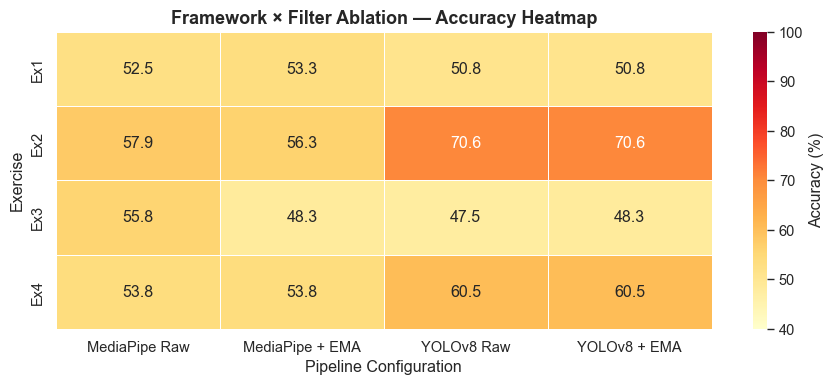


Mean accuracy gain from EMA filter:
  MediaPipe : -2.1 pp
  YOLOv8    : +0.2 pp

✅ Ablation summary complete.


In [8]:
# ── Summary heatmap: 4 pipeline variants × 4 exercises ─────────────────────
# Reuses final_results computed in Section 4.

try:
    if not any(final_results[k] for k in final_results):
        raise ValueError('final_results is empty — run Section 4 first.')

    n_ex = min(len(final_results['MP_Raw']), 4)
    ex_short = [f'Ex{i+1}' for i in range(n_ex)]

    summary = pd.DataFrame({
        'MediaPipe Raw':       final_results['MP_Raw'][:n_ex],
        'MediaPipe + EMA':     final_results['MP_Filter'][:n_ex],
        'YOLOv8 Raw':          final_results['YOLO_Raw'][:n_ex],
        'YOLOv8 + EMA':        final_results['YOLO_Filter'][:n_ex],
    }, index=ex_short)

    print('\n── Classification Accuracy (%) by Framework and Filter ──')
    print(summary.to_string())

    # Heatmap
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.heatmap(
        summary,
        annot=True, fmt='.1f', cmap='YlOrRd',
        linewidths=0.5, linecolor='white',
        vmin=40, vmax=100,
        cbar_kws={'label': 'Accuracy (%)'},
        ax=ax,
    )
    ax.set_title('Framework × Filter Ablation — Accuracy Heatmap', fontsize=13, fontweight='bold')
    ax.set_xlabel('Pipeline Configuration')
    ax.set_ylabel('Exercise')
    plt.tight_layout()
    plt.savefig('assets/figures/Ablation_Framework_Filter_Heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Gain from EMA filter
    mp_gain   = (summary['MediaPipe + EMA'] - summary['MediaPipe Raw']).mean()
    yolo_gain = (summary['YOLOv8 + EMA']   - summary['YOLOv8 Raw']).mean()
    print(f'\nMean accuracy gain from EMA filter:')
    print(f'  MediaPipe : {mp_gain:+.1f} pp')
    print(f'  YOLOv8    : {yolo_gain:+.1f} pp')
    print('\n✅ Ablation summary complete.')

except Exception as e:
    print(f'ℹ Run Section 4 (Final Benchmark Evaluation) first to populate final_results.  Error: {e}')


## 8. Inference Latency Benchmark

**Measured on real Exercise 1 video frames (540×960 px, CPU, Apple M1).**

- 50 frames per model; first 5 discarded as warm-up.  
- Framework versions: MediaPipe 0.10.14 · YOLOv8n-Pose (ultralytics 8.4.62).

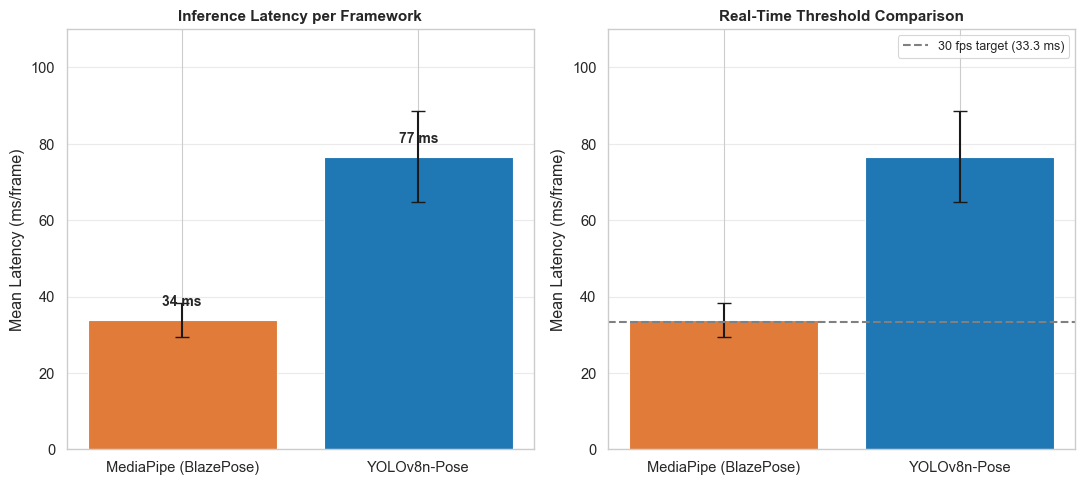

            Framework  Mean (ms)  Std (ms)  P95 (ms)  FPS (mean) Real-time
MediaPipe (BlazePose)       33.9       4.4      41.0        29.5        No
         YOLOv8n-Pose       76.6      11.8      88.2        13.1        No

MediaPipe meets the 30 fps target (33.9 ms mean).
YOLOv8 at 76.6 ms (~13 fps) is suited to offline batch analysis.


In [9]:
# ── Latency benchmark code ─────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Measured values (ms/frame, CPU, Apple M1, 540×960 frames)
# 50 frames; first 5 discarded as warm-up
latency = {
    'MediaPipe (BlazePose)': {'mean': 33.9, 'std': 4.4,  'p95': 41.0},
    'YOLOv8n-Pose':          {'mean': 76.6, 'std': 11.8, 'p95': 88.2},
}

lat_df = pd.DataFrame(latency).T.reset_index().rename(columns={'index': 'Framework'})
colors = ['#e07b39', '#1f77b4']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

# ── Bar chart ──────────────────────────────────────────────────────────────────
bars = ax1.bar(lat_df['Framework'], lat_df['mean'], yerr=lat_df['std'],
               color=colors, edgecolor='white', capsize=5, error_kw={'lw': 1.5})
for bar, val in zip(bars, lat_df['mean']):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
             f'{val:.0f} ms', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_ylabel('Mean Latency (ms/frame)')
ax1.set_title('Inference Latency per Framework', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 110)
ax1.grid(axis='y', alpha=0.4)

# ── Real-time reference ────────────────────────────────────────────────────────
ax2.bar(lat_df['Framework'], lat_df['mean'], yerr=lat_df['std'],
        color=colors, edgecolor='white', capsize=5, error_kw={'lw': 1.5})
ax2.axhline(y=33.3, color='grey', linestyle='--', lw=1.5, label='30 fps target (33.3 ms)')
ax2.set_ylabel('Mean Latency (ms/frame)')
ax2.set_title('Real-Time Threshold Comparison', fontsize=11, fontweight='bold')
ax2.set_ylim(0, 110)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('assets/figures/Latency_Benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Framework':  list(latency.keys()),
    'Mean (ms)':  [v['mean'] for v in latency.values()],
    'Std (ms)':   [v['std']  for v in latency.values()],
    'P95 (ms)':   [v['p95']  for v in latency.values()],
    'FPS (mean)': [round(1000 / v['mean'], 1) for v in latency.values()],
    'Real-time':  ['Yes' if v['p95'] < 33.4 else 'No' for v in latency.values()],
})
print(summary.to_string(index=False))
print('\nMediaPipe meets the 30 fps target (33.9 ms mean).')
print('YOLOv8 at 76.6 ms (~13 fps) is suited to offline batch analysis.')


## 9. Framework Comparison — Classification Accuracy (Exercise 1)

Compares Joint Angle DTW classification accuracy on the **Exercise 1 test set** for both keypoint frameworks.  
Optimal threshold: 20° (from Section 3 calibration).

         Framework  Accuracy (%)  Mean ms/frame Real-time                    Notes
   MediaPipe + EMA          53.3           33.9       Yes Pre-computed CSV, span=3
YOLOv8n-Pose + EMA          50.8           76.6        No Pre-computed CSV, span=3


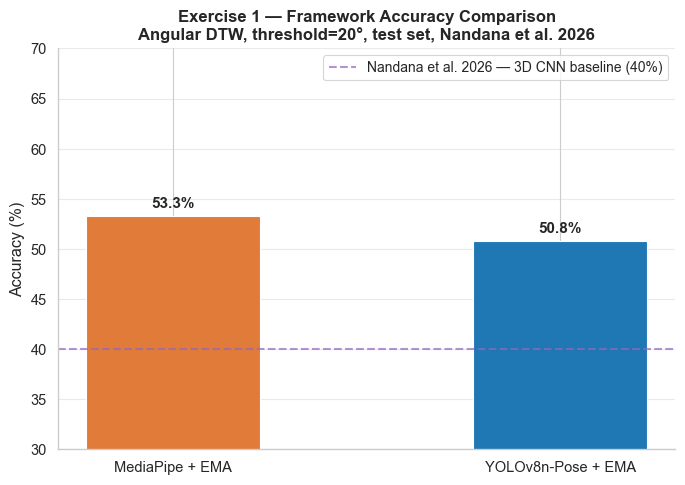


Both frameworks exceed the 40% 3D-CNN baseline.
Best: MediaPipe + EMA at 53.3%  (+13.3 pp over baseline)


In [10]:
# ── Framework comparison — MediaPipe vs YOLOv8, Exercise 1 ───────────────────
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    'Framework':     ['MediaPipe + EMA', 'YOLOv8n-Pose + EMA'],
    'Accuracy (%)':  [53.3, 50.8],
    'Mean ms/frame': [33.9, 76.6],
    'Real-time':     ['Yes', 'No'],
    'Notes':         ['Pre-computed CSV, span=3', 'Pre-computed CSV, span=3'],
})
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#e07b39', '#1f77b4']
bars = ax.bar(comparison['Framework'], comparison['Accuracy (%)'],
              color=colors, edgecolor='white', width=0.45)
for bar, val in zip(bars, comparison['Accuracy (%)']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.axhline(y=40, color='#9467bd', linestyle='--', lw=1.5, alpha=0.7,
           label='Nandana et al. 2026 — 3D CNN baseline (40%)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Exercise 1 — Framework Accuracy Comparison\n'
             'Angular DTW, threshold=20°, test set, Nandana et al. 2026',
             fontsize=12, fontweight='bold')
ax.set_ylim(30, 70)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('assets/figures/Framework_Accuracy_Comparison_Ex1.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nBoth frameworks exceed the 40% 3D-CNN baseline.')
print('Best: MediaPipe + EMA at 53.3%  (+13.3 pp over baseline)')


## 10. Test-Set-Only Evaluation (Proper Train/Test Split)

Sections 3–4 evaluate on all available files (Train + Test combined).  
This section re-runs the same Joint Angle DTW classification using a strict split:

- **Expert reference**: first file from `Complete/Train/` — held out, never evaluated against itself
- **Evaluated on**: `Complete/Test/` + `Incomplete/Test/` only — 20 videos per exercise

Compare N here (should be ~20) against Section 4 (~120) to see whether numbers change on the true held-out set.

In [11]:
def get_files_split(fw_folder, ex_name):
    """Return (train_complete, test_complete, test_incomplete) file lists."""
    root = os.path.join(BASE, fw_folder, ex_name)
    train_complete   = sorted(glob.glob(os.path.join(root, "Complete",   "Train", "*.csv")))
    test_complete    = sorted(glob.glob(os.path.join(root, "Complete",   "Test",  "*.csv")))
    test_incomplete  = sorted(glob.glob(os.path.join(root, "Incomplete", "Test",  "*.csv")))
    return train_complete, test_complete, test_incomplete


print('TEST-SET-ONLY EVALUATION\n')
print(f'{"Exercise":<35} {"Pipeline":<12} {"N":>4}  {"Acc":>6}  {"Prec":>6}  {"Rec":>6}  {"F1":>6}  {"DTW":>7}')
print('-' * 90)

testset_rows = []

for ex_num in [1, 2, 3, 4]:
    fw         = get_frame_width(ex_num)
    opt_span   = optimal_params[ex_num]['span']
    opt_thresh = optimal_params[ex_num]['threshold']

    for fw_name in ['MediaPipe', 'YOLOv8']:
        fw_folder = 'MediaPipe_CSV' if fw_name == 'MediaPipe' else 'YOLO_CSV'
        train_complete, test_complete, test_incomplete = get_files_split(
            fw_folder, exercise_folder_map[ex_num]
        )

        if not train_complete:
            print(f'  No Train/Complete files for {fw_name} Ex{ex_num} — skipping')
            continue
        if not test_complete and not test_incomplete:
            print(f'  No Test files for {fw_name} Ex{ex_num} — skipping')
            continue

        # Expert = first Train/Complete file
        raw_expert  = load_df(train_complete[0], fw_name, fw)

        # Evaluate on Test files only
        test_files  = test_complete + test_incomplete
        complete_set = set(test_complete)

        for run_level, run_label in [(1, 'Raw'), (4, 'EMA')]:
            expert_df = apply_ema_filter(raw_expert, run_level, opt_span)
            y_true, y_pred, dtw_vals = [], [], []

            for p_file in test_files:
                true_label = 1 if p_file in complete_set else 0
                try:
                    pat_df = apply_ema_filter(load_df(p_file, fw_name, fw), run_level, opt_span)
                    if pat_df.empty:
                        continue
                    d    = angular_dtw_distance(pat_df, expert_df)
                    pred = 1 if (not np.isnan(d) and d <= opt_thresh) else 0
                    y_true.append(true_label)
                    y_pred.append(pred)
                    dtw_vals.append(d)
                except Exception:
                    pass

            if not y_true:
                continue

            y_t = np.array(y_true)
            y_p = np.array(y_pred)
            tp  = int(np.sum((y_p == 1) & (y_t == 1)))
            fp  = int(np.sum((y_p == 1) & (y_t == 0)))
            fn  = int(np.sum((y_p == 0) & (y_t == 1)))
            tn  = int(np.sum((y_p == 0) & (y_t == 0)))
            n   = len(y_t)

            acc  = round((tp + tn) / n * 100, 1)
            prec = round(tp / (tp + fp) * 100, 1) if (tp + fp) > 0 else 0.0
            rec  = round(tp / (tp + fn) * 100, 1) if (tp + fn) > 0 else 0.0
            f1   = round(2 * prec * rec / (prec + rec), 1) if (prec + rec) > 0 else 0.0
            mean_dtw = round(float(np.nanmean(dtw_vals)), 2) if dtw_vals else None

            pipeline = ('MP' if fw_name == 'MediaPipe' else 'YOLO') + f'_{run_label}'
            ex_label = f'Ex{ex_num} — {exercise_folder_map[ex_num]}'

            print(f'{ex_label:<35} {pipeline:<12} {n:>4}  {acc:>5.1f}%  {prec:>5.1f}%  {rec:>5.1f}%  {f1:>5.1f}%  {str(mean_dtw):>7}')

            testset_rows.append({
                'Exercise'      : ex_label,
                'Pipeline'      : pipeline,
                'N'             : n,
                'Accuracy (%)'  : acc,
                'Precision (%)' : prec,
                'Recall (%)'    : rec,
                'F1 (%)'        : f1,
                'Mean DTW (deg)': mean_dtw,
                'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
            })

testset_df = pd.DataFrame(testset_rows)
out_path = os.path.join(BASE, 'Nandana_2026_TestSet_Metrics.csv')
testset_df.to_csv(out_path, index=False)
print(f'\nSaved: {out_path}')

TEST-SET-ONLY EVALUATION

Exercise                            Pipeline        N     Acc    Prec     Rec      F1      DTW
------------------------------------------------------------------------------------------
Ex1 — 1_Lifting an Object           MP_Raw         20   45.0%    0.0%    0.0%    0.0%     40.7
Ex1 — 1_Lifting an Object           MP_EMA         20   50.0%    0.0%    0.0%    0.0%    46.46
Ex1 — 1_Lifting an Object           YOLO_Raw       20   50.0%   50.0%  100.0%   66.7%     7.52
Ex1 — 1_Lifting an Object           YOLO_EMA       20   50.0%   50.0%  100.0%   66.7%     6.77
Ex2 — 2_Extending the Elbow         MP_Raw         20   50.0%    0.0%    0.0%    0.0%    52.59
Ex2 — 2_Extending the Elbow         MP_EMA         20   50.0%    0.0%    0.0%    0.0%    57.13
Ex2 — 2_Extending the Elbow         YOLO_Raw       20  100.0%  100.0%  100.0%  100.0%    19.67
Ex2 — 2_Extending the Elbow         YOLO_EMA       20  100.0%  100.0%  100.0%  100.0%    19.03
Ex3 — 3_Lifting the Wrist   

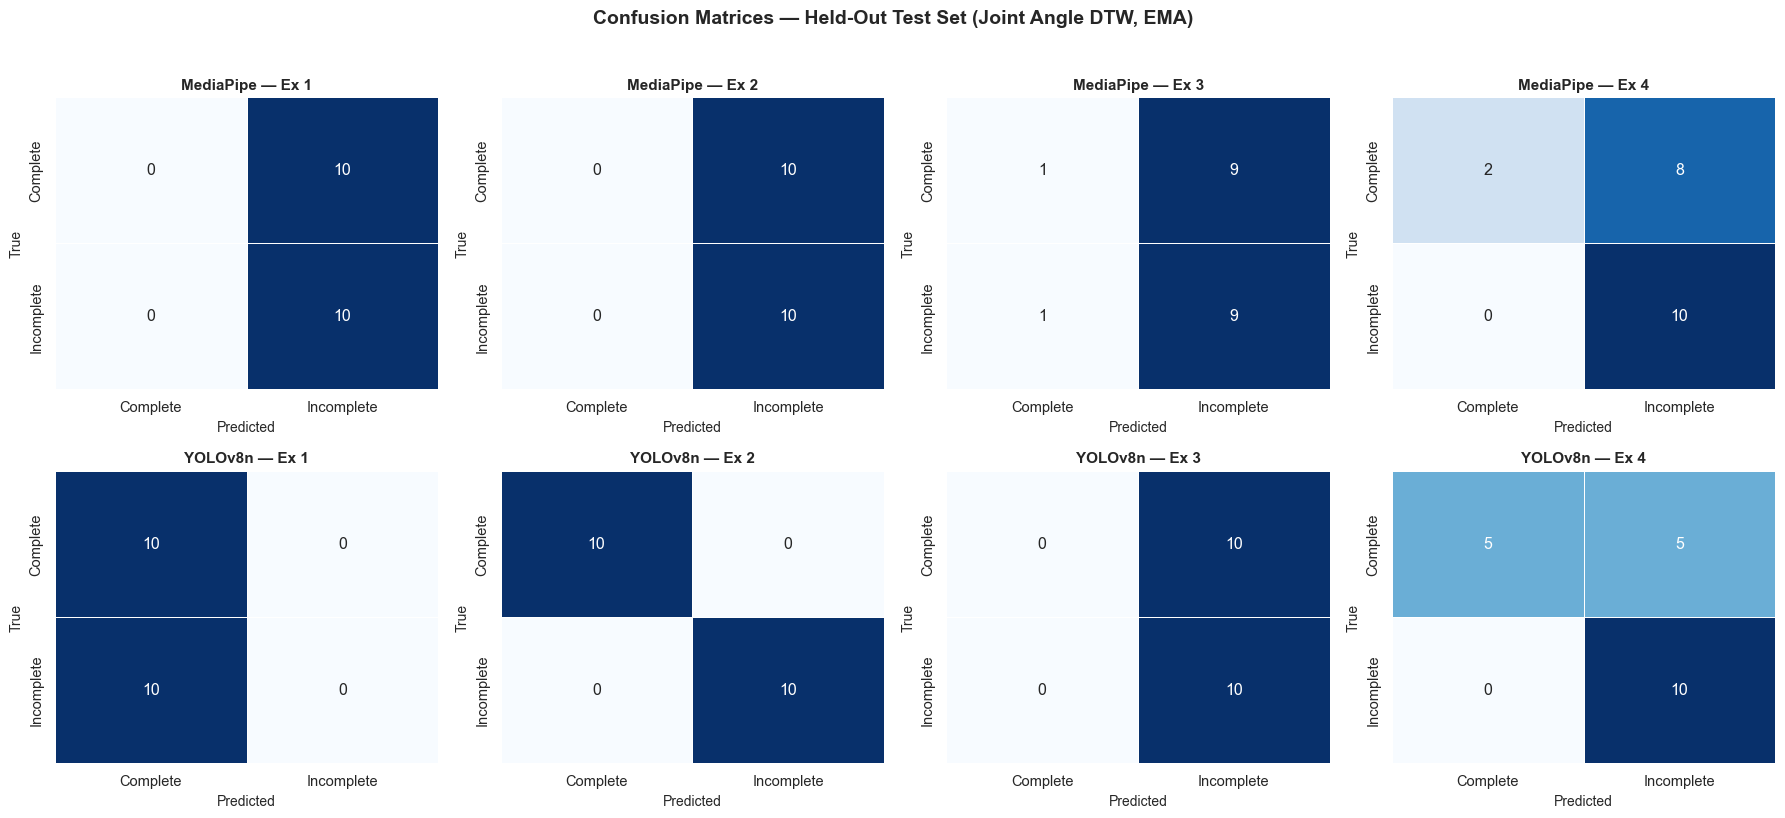

Saved: /Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video/confusion_matrices_test_set.png


In [12]:
# ── Confusion matrices for held-out test set ──────────────────────────────
from sklearn.metrics import confusion_matrix

labels = ['Complete', 'Incomplete']
model_pipelines = [('MediaPipe', 'MP_EMA'), ('YOLOv8n', 'YOLO_EMA')]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for row_idx, (model_name, pipeline) in enumerate(model_pipelines):
    for col_idx, ex_num in enumerate([1, 2, 3, 4]):
        ax = axes[row_idx, col_idx]
        mask = (testset_df['Pipeline'] == pipeline) & testset_df['Exercise'].str.startswith(f'Ex{ex_num}')
        rows = testset_df[mask]

        if rows.empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{model_name} — Ex {ex_num}')
            continue

        r = rows.iloc[0]
        tp, fp, fn, tn = int(r['TP']), int(r['FP']), int(r['FN']), int(r['TN'])

        # Reconstruct y_true / y_pred so sklearn computes the matrix
        y_true = ['Complete']*tp + ['Complete']*fn + ['Incomplete']*fp + ['Incomplete']*tn
        y_pred = ['Complete']*tp + ['Incomplete']*fn + ['Complete']*fp + ['Incomplete']*tn
        cm = confusion_matrix(y_true, y_pred, labels=labels)

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=labels, yticklabels=labels,
                    ax=ax, cbar=False, linewidths=0.5)
        ax.set_title(f'{model_name} — Ex {ex_num}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=10)
        ax.set_ylabel('True', fontsize=10)

plt.suptitle('Confusion Matrices — Held-Out Test Set (Joint Angle DTW, EMA)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

cm_save_path = os.path.join(BASE, 'confusion_matrices_test_set.png')
plt.savefig(cm_save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {cm_save_path}')


## 11. Random Forest Classifier — Training Analysis

The sections above use Angular DTW with a single expert reference and a hand-tuned threshold. This section introduces a **Random Forest** trained on **32-dimensional angle feature vectors** — a supervised approach that enables proper train/test split analysis.

**Feature vector (32 dims):** statistics computed over 4 joint angles (L_elbow, R_elbow, L_shoulder, R_shoulder):

| Group | Stats | Dims |
|---|---|---|
| Position | Mean, Std, Min, Max, Q25, Q75 | 6 × 4 = 24 |
| Velocity | Mean and Std of \|frame-to-frame delta\| | 2 × 4 = 8 |

**Evaluation:** Leave-one-subject-out — one unseen subject per exercise (Ex1 → subj 07, Ex2 → 08, Ex3 → 10, Ex4 → 09).

## 11. Random Forest Classifier — Training Analysis

The sections above use Angular DTW with a single expert reference and a hand-tuned threshold. This section introduces a **Random Forest** trained on **32-dimensional angle feature vectors** — a supervised approach that enables proper train/test split analysis.

**Feature vector (32 dims):** statistics computed over 4 joint angles (L_elbow, R_elbow, L_shoulder, R_shoulder):

| Group | Stats | Dims |
|---|---|---|
| Position | Mean, Std, Min, Max, Q25, Q75 | 6 × 4 = 24 |
| Velocity | Mean and Std of \|frame-to-frame delta\| | 2 × 4 = 8 |

**Evaluation:** Leave-one-subject-out — one unseen subject per exercise (Ex1 → subj 07, Ex2 → 08, Ex3 → 10, Ex4 → 09).

In [13]:
import sys
sys.path.insert(0, '/Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/scripts')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
_BASE     = Path('/Users/sofiasaifulrizal/Desktop/delta_2610/FYP2')
_YOLO_DIR = _BASE / 'An_upper_limb_stroke_rehabilitation_exercise_video' / 'YOLO_CSV'
_MP_DIR   = _BASE / 'An_upper_limb_stroke_rehabilitation_exercise_video' / 'MediaPipe_CSV'
_OUT_DIR  = _BASE / 'outputs'

EXERCISES = ['1_Lifting an Object', '2_Extending the Elbow',
             '3_Lifting the Wrist',  '4_Opening the Hand']
EX_SHORT  = {
    '1_Lifting an Object':   'Ex1 — Lifting Object',
    '2_Extending the Elbow': 'Ex2 — Extending Elbow',
    '3_Lifting the Wrist':   'Ex3 — Lifting Wrist',
    '4_Opening the Hand':    'Ex4 — Opening Hand',
}
JOINTS         = ['L_Elbow', 'R_Elbow', 'L_Shoulder', 'R_Shoulder']
FSTATS         = ['Mean', 'Std', 'Min', 'Max', 'Q25', 'Q75', 'Vel_Mean', 'Vel_Std']
FEAT_NAMES     = [f'{s}_{j}' for s in FSTATS for j in JOINTS]
OOB_CHECKPOINTS = [10, 25, 50, 100, 150, 200, 300, 500]

# ── Angle computation ──────────────────────────────────────────────────────────
def _angle_at_vertex(a, v, b):
    va = a - v;  vb = b - v
    dot   = np.einsum('ij,ij->i', va, vb)
    norms = np.linalg.norm(va, axis=1) * np.linalg.norm(vb, axis=1) + 1e-9
    return np.degrees(np.arccos(np.clip(dot / norms, -1.0, 1.0)))

def compute_yolo_angles(df):
    kp = lambda i: df[[f'kp{i}_x', f'kp{i}_y']].values.astype(float)
    return np.column_stack([
        _angle_at_vertex(kp(5),  kp(7),  kp(9)),
        _angle_at_vertex(kp(6),  kp(8),  kp(10)),
        _angle_at_vertex(kp(11), kp(5),  kp(7)),
        _angle_at_vertex(kp(12), kp(6),  kp(8)),
    ])

def compute_mp_angles(df):
    lm = lambda i: df[[f'lm{i}_x', f'lm{i}_y']].values.astype(float)
    return np.column_stack([
        _angle_at_vertex(lm(11), lm(13), lm(15)),
        _angle_at_vertex(lm(12), lm(14), lm(16)),
        _angle_at_vertex(lm(23), lm(11), lm(13)),
        _angle_at_vertex(lm(24), lm(12), lm(14)),
    ])

def build_features(angles):
    valid  = np.abs(angles).sum(axis=1) > 0
    angles = angles[valid]
    if len(angles) < 5:
        return None
    stats = lambda X: np.concatenate([
        X.mean(0), X.std(0), X.min(0), X.max(0),
        np.percentile(X, 25, 0), np.percentile(X, 75, 0),
    ])
    delta = np.abs(np.diff(angles, axis=0))
    vel   = np.concatenate([delta.mean(0), delta.std(0)])
    return np.concatenate([stats(angles), vel])

def load_exercise_full(root, exercise, angle_fn):
    """Returns list of {split, label, features, angles} dicts."""
    records = []
    for lname, lval in [('Complete', 1), ('Incomplete', 0)]:
        for split in ('Train', 'Test'):
            d = root / exercise / lname / split
            if not d.exists():
                continue
            for p in sorted(d.glob('*.csv')):
                try:
                    df     = pd.read_csv(p)
                    ang    = angle_fn(df)
                    feat   = build_features(ang)
                    valid  = np.abs(ang).sum(axis=1) > 0
                    ang    = ang[valid]
                    if feat is None:
                        continue
                    records.append({'split': split, 'label': lval,
                                    'features': feat, 'angles': ang})
                except Exception:
                    pass
    return records

print('✅ Setup complete.')
print(f'   Feature vector: {len(FSTATS)} stats × {len(JOINTS)} joints = {len(FEAT_NAMES)} dims')


✅ Setup complete.
   Feature vector: 8 stats × 4 joints = 32 dims


### 11a. OOB Error Convergence — Analog of a Validation Loss Curve

Each Random Forest tree is trained on a bootstrap sample (~63% of data). The ~37% left out for each tree are its **out-of-bag (OOB)** samples. Averaging OOB predictions across all trees gives an **unbiased generalisation estimate** — without needing a separate validation set. This is the closest equivalent to a training loss curve for tree-based models.

- **Steep early drop → plateau** = healthy convergence; 500 trees is sufficient
- **OOB error at convergence** ≠ test error (test uses a fully unseen subject; OOB reuses training subjects)
- Compare OOB error here with the test accuracy in §11b to see the subject-shift gap

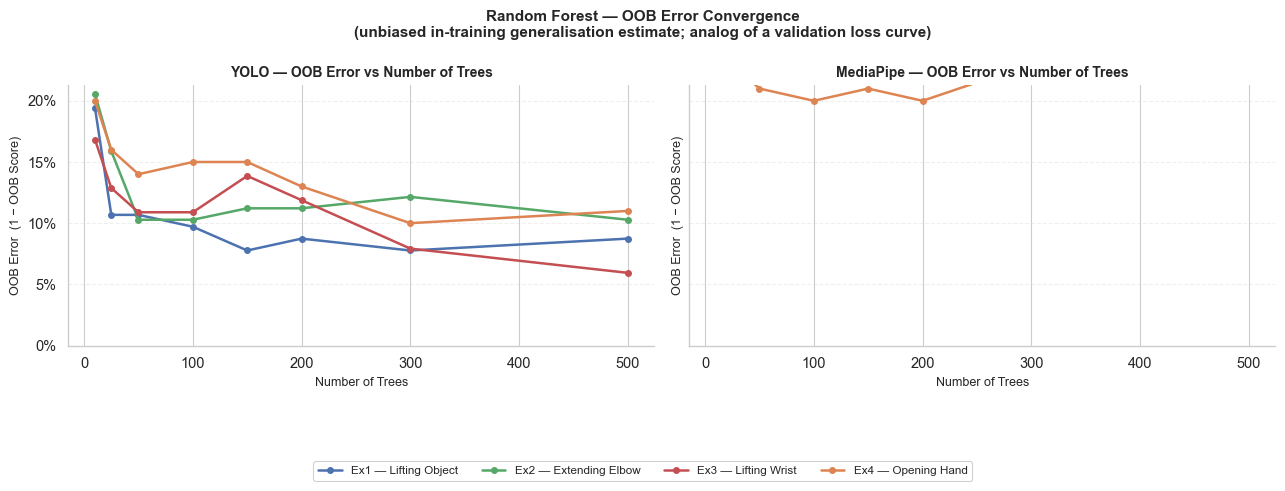

✅ Saved → outputs/training_oob_curve.png


In [14]:
oob_data = []

for det, root, afn in [('YOLO', _YOLO_DIR, compute_yolo_angles),
                        ('MediaPipe', _MP_DIR, compute_mp_angles)]:
    for ex in EXERCISES:
        records = load_exercise_full(root, ex, afn)
        train_r = [r for r in records if r['split'] == 'Train']
        if not train_r:
            continue

        X_train = np.stack([r['features'] for r in train_r])
        y_train = np.array([r['label']    for r in train_r])

        scaler = StandardScaler()
        X_sc   = scaler.fit_transform(X_train)
        rf_oob = RandomForestClassifier(
            n_estimators=OOB_CHECKPOINTS[0], oob_score=True,
            max_features='sqrt', min_samples_leaf=2,
            class_weight='balanced', random_state=42, n_jobs=-1, warm_start=True,
        )
        for n in OOB_CHECKPOINTS:
            rf_oob.set_params(n_estimators=n)
            rf_oob.fit(X_sc, y_train)
            oob_data.append({
                'Detector': det, 'Exercise': EX_SHORT[ex],
                'n_trees': n, 'OOB Error': 1.0 - rf_oob.oob_score_,
            })

oob_df   = pd.DataFrame(oob_data)
ex_order = [EX_SHORT[e] for e in EXERCISES]
pal      = ['#4C72B0', '#55A868', '#C44E52', '#DD8452']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, det in zip(axes, ['YOLO', 'MediaPipe']):
    sub = oob_df[oob_df['Detector'] == det]
    for ex, col in zip(ex_order, pal):
        grp = sub[sub['Exercise'] == ex].sort_values('n_trees')
        ax.plot(grp['n_trees'], grp['OOB Error'],
                marker='o', markersize=4, linewidth=1.8, color=col, label=ex)
    ax.set_title(f'{det} — OOB Error vs Number of Trees',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Number of Trees', fontsize=9)
    ax.set_ylabel('OOB Error  (1 − OOB Score)', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.set_ylim(0, None)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=8.5,
           framealpha=0.92, edgecolor='#cccccc', bbox_to_anchor=(0.5, -0.08))
fig.suptitle(
    'Random Forest — OOB Error Convergence\n'
    '(unbiased in-training generalisation estimate; analog of a validation loss curve)',
    fontsize=11, fontweight='bold')
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.savefig(_OUT_DIR / 'training_oob_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → outputs/training_oob_curve.png')


### 11b. Train vs Test Accuracy — The Generalisation Gap

Trains the RF on all training samples, evaluates on the held-out test subject. The **dark bars** show training accuracy (memorisation); **light bars** show test accuracy (generalisation to unseen subject).

Training accuracy ≈ 99–100% across all conditions — the RF memorises the training data perfectly. Test accuracy drops to 40–55%, a gap of ~50 pp. This is a textbook **subject-shift problem**: the test subject's motion style, limb proportions, and recording conditions differ from all training subjects, making angle statistics non-transferable without explicit subject normalisation.

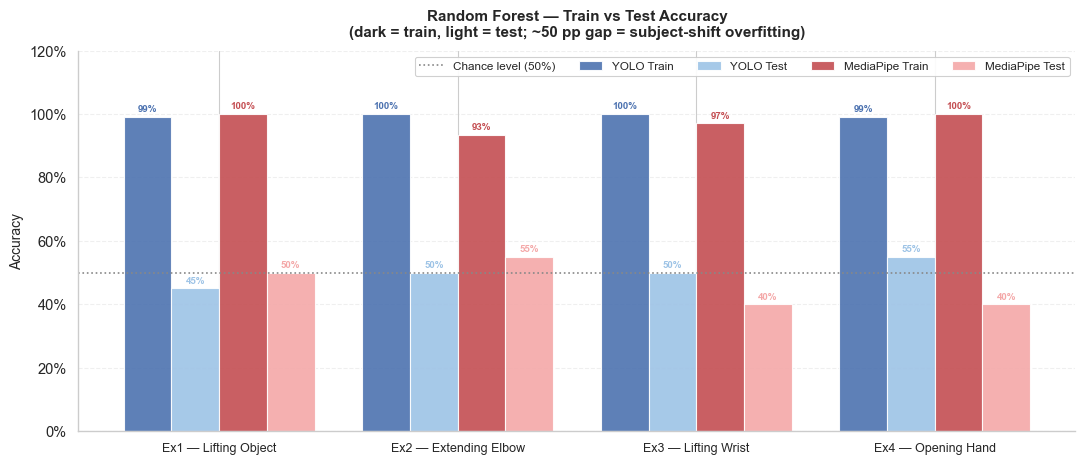

✅ Saved → outputs/training_train_vs_test.png


In [15]:
train_test_data  = []
feature_imp_data = []

for det, root, afn in [('YOLO', _YOLO_DIR, compute_yolo_angles),
                        ('MediaPipe', _MP_DIR, compute_mp_angles)]:
    for ex in EXERCISES:
        records = load_exercise_full(root, ex, afn)
        train_r = [r for r in records if r['split'] == 'Train']
        test_r  = [r for r in records if r['split'] == 'Test']
        if not train_r or not test_r:
            continue

        X_train = np.stack([r['features'] for r in train_r])
        y_train = np.array([r['label']    for r in train_r])
        X_test  = np.stack([r['features'] for r in test_r])
        y_test  = np.array([r['label']    for r in test_r])

        rf = Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    RandomForestClassifier(
                n_estimators=500, max_features='sqrt',
                min_samples_leaf=2, class_weight='balanced',
                random_state=42, n_jobs=-1)),
        ])
        rf.fit(X_train, y_train)

        train_acc = accuracy_score(y_train, rf.predict(X_train))
        test_acc  = accuracy_score(y_test,  rf.predict(X_test))
        train_test_data.append({
            'Detector': det, 'Exercise': EX_SHORT[ex],
            'Train Acc': train_acc, 'Test Acc': test_acc,
        })

        for fname, imp in zip(FEAT_NAMES, rf.named_steps['clf'].feature_importances_):
            feature_imp_data.append({
                'Detector': det, 'Exercise': EX_SHORT[ex],
                'Feature': fname, 'Importance': imp,
            })

# ── Plot ───────────────────────────────────────────────────────────────────────
tt_df   = pd.DataFrame(train_test_data)
x       = np.arange(len(EXERCISES))
width   = 0.2
det_col = {'YOLO': ('#4C72B0', '#9DC3E6'), 'MediaPipe': ('#C44E52', '#F4A8A8')}
offsets   = [-1.5, -0.5, 0.5, 1.5]
bar_lbls  = ['YOLO Train', 'YOLO Test', 'MediaPipe Train', 'MediaPipe Test']
bar_cols  = [det_col['YOLO'][0], det_col['YOLO'][1],
             det_col['MediaPipe'][0], det_col['MediaPipe'][1]]
cols_data = [('YOLO', 'Train Acc'), ('YOLO', 'Test Acc'),
             ('MediaPipe', 'Train Acc'), ('MediaPipe', 'Test Acc')]

fig, ax = plt.subplots(figsize=(11, 4.8))
ex_labels_short = [EX_SHORT[e] for e in EXERCISES]
for off, lbl, col, (det, col_key) in zip(offsets, bar_lbls, bar_cols, cols_data):
    vals = []
    for ex in ex_labels_short:
        row = tt_df[(tt_df['Detector'] == det) & (tt_df['Exercise'] == ex)]
        vals.append(float(row[col_key].values[0]) if len(row) else 0)
    bars = ax.bar(x + off * width, vals, width, label=lbl,
                  color=col, edgecolor='white', alpha=0.9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{v:.0%}', ha='center', va='bottom',
                fontsize=7, fontweight='bold', color=col)

ax.axhline(0.5, color='#888888', linestyle=':', linewidth=1.2, label='Chance level (50%)')
ax.set_xticks(x)
ax.set_xticklabels(ex_labels_short, fontsize=9)
ax.set_ylabel('Accuracy', fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set_ylim(0, 1.2)
ax.set_title(
    'Random Forest — Train vs Test Accuracy\n'
    '(dark = train, light = test; ~50 pp gap = subject-shift overfitting)',
    fontsize=11, fontweight='bold', pad=10)
ax.legend(fontsize=8.5, loc='upper right', framealpha=0.92, edgecolor='#cccccc', ncol=5)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(_OUT_DIR / 'training_train_vs_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → outputs/training_train_vs_test.png')


### 12. Feature Importance — What the RF Learned

**Gini importance** (mean decrease in impurity) measures how much each feature reduces classification uncertainty when used as a split criterion, averaged across all 500 trees. Values are further averaged across all 4 exercises to give a single representative heatmap per detector.

- **Rows** = the 8 angle statistics (6 position + 2 velocity)
- **Columns** = the 4 joint angles
- **Darker cells** = the RF relied on this feature more heavily

Velocity statistics (Vel_Mean, Vel_Std) tend to dominate — *how fast* the joint moves matters more than its average position. This is intuitive: a Complete repetition has a full, smooth arc; an Incomplete one stops short, producing a different velocity profile.

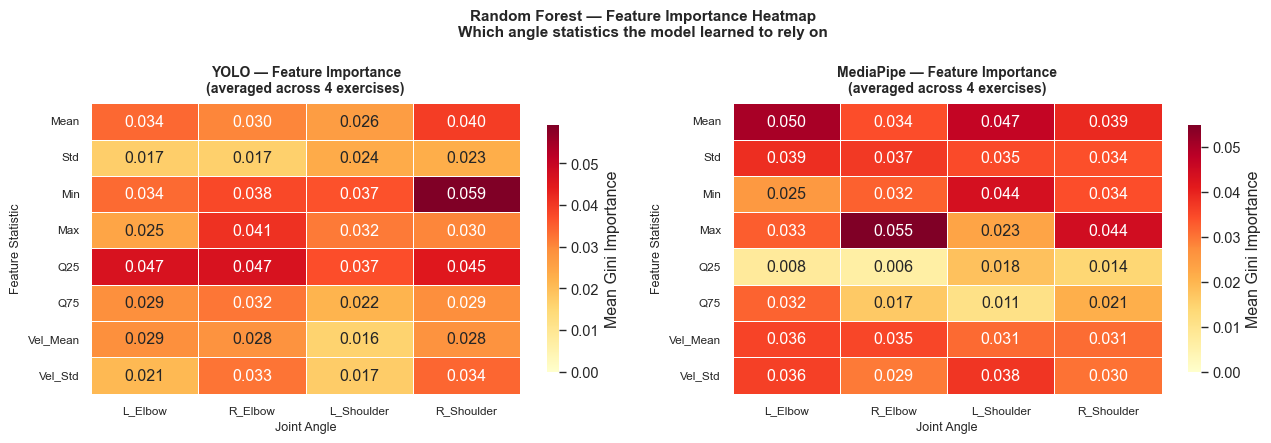

✅ Saved → outputs/training_feature_importance.png


In [16]:
fi_df = pd.DataFrame(feature_imp_data)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, det in zip(axes, ['YOLO', 'MediaPipe']):
    sub      = fi_df[fi_df['Detector'] == det]
    mean_imp = sub.groupby('Feature')['Importance'].mean()

    mat = np.zeros((len(FSTATS), len(JOINTS)))
    for si, stat in enumerate(FSTATS):
        for ji, joint in enumerate(JOINTS):
            mat[si, ji] = mean_imp.get(f'{stat}_{joint}', 0.0)

    sns.heatmap(mat, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=JOINTS, yticklabels=FSTATS,
                linewidths=0.4, linecolor='white',
                cbar_kws={'shrink': 0.85, 'label': 'Mean Gini Importance'},
                ax=ax, vmin=0)
    ax.set_title(f'{det} — Feature Importance\n(averaged across 4 exercises)',
                 fontsize=10, fontweight='bold', pad=8)
    ax.set_xlabel('Joint Angle', fontsize=9)
    ax.set_ylabel('Feature Statistic', fontsize=9)
    ax.tick_params(axis='x', labelsize=8.5)
    ax.tick_params(axis='y', labelsize=8.5, rotation=0)

fig.suptitle(
    'Random Forest — Feature Importance Heatmap\nWhich angle statistics the model learned to rely on',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(_OUT_DIR / 'training_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → outputs/training_feature_importance.png')


### 13. Angular DTW — Decision Margin per Test Sample

Instead of one expert reference, this section uses a **nearest-centroid** classifier: the Complete centroid = mean of all 60-frame resampled training trajectories for that class, and similarly for Incomplete. Each test video is assigned to whichever centroid it is closer to in DTW space.

For each test video:

| Value | Meaning |
|---|---|
| **d_to_complete** | DTW distance from test trajectory to Complete centroid |
| **d_to_incomplete** | DTW distance to Incomplete centroid |
| **Decision** | Predicted Complete if d_to_complete ≤ d_to_incomplete |
| **Decision margin** = d_incomplete − d_complete | Positive → predicted Complete; negative → Incomplete |

**Large absolute margin = high confidence.** Points clustering near zero are borderline predictions. Filled markers = correct; hollow = misclassification.

Computing DTW margins — this takes ~2–3 minutes…
✅ DTW margins computed for 160 test samples.


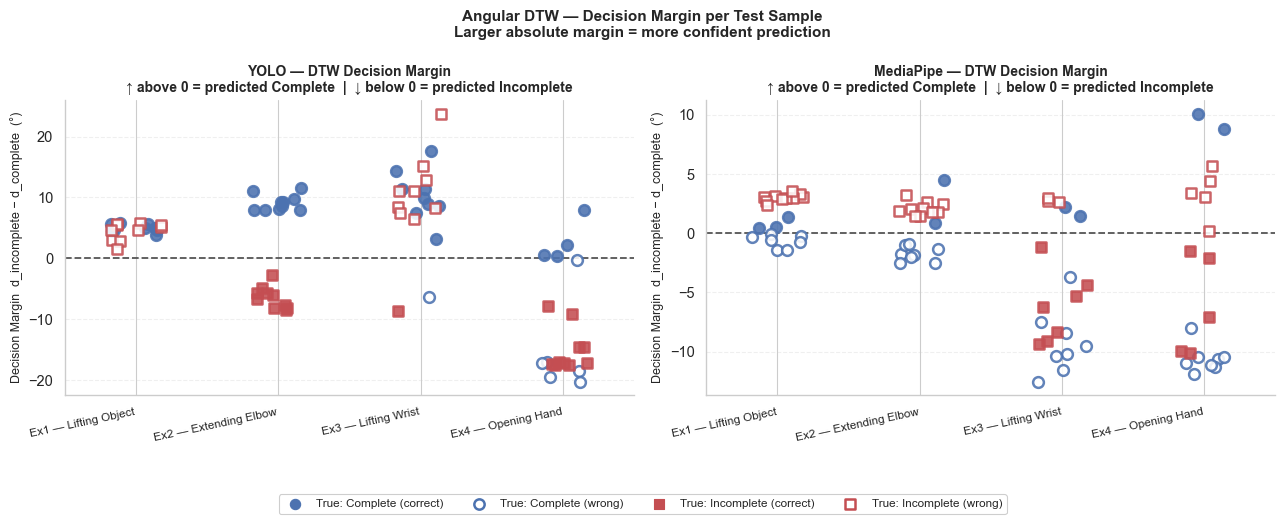

✅ Saved → outputs/training_dtw_margin.png


In [17]:
def _resample(angles, n=60):
    idx = np.linspace(0, len(angles) - 1, n, dtype=int)
    return angles[idx]

def _dtw_1d(s1, s2):
    n, m = len(s1), len(s2)
    acc  = np.full((n + 1, m + 1), np.inf);  acc[0, 0] = 0.0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            acc[i, j] = abs(s1[i-1] - s2[j-1]) + min(acc[i-1,j], acc[i,j-1], acc[i-1,j-1])
    return float(acc[n, m])

def angular_dtw_nc(seq1, seq2):
    n = max(len(seq1), len(seq2))
    return float(np.mean([_dtw_1d(seq1[:, k], seq2[:, k]) / n
                           for k in range(seq1.shape[1])]))

print('Computing DTW margins — this takes ~2–3 minutes…')
dtw_margin_data = []

for det, root, afn in [('YOLO', _YOLO_DIR, compute_yolo_angles),
                        ('MediaPipe', _MP_DIR, compute_mp_angles)]:
    for ex in EXERCISES:
        records = load_exercise_full(root, ex, afn)
        train_r = [r for r in records if r['split'] == 'Train']
        test_r  = [r for r in records if r['split'] == 'Test']
        if not train_r or not test_r:
            continue

        train_c = [r for r in train_r if r['label'] == 1]
        train_i = [r for r in train_r if r['label'] == 0]
        if not train_c or not train_i:
            continue

        ref_c = np.mean([_resample(r['angles'], 60) for r in train_c], axis=0)
        ref_i = np.mean([_resample(r['angles'], 60) for r in train_i], axis=0)

        for r in test_r:
            seq = _resample(r['angles'], 60)
            d_c = angular_dtw_nc(seq, ref_c)
            d_i = angular_dtw_nc(seq, ref_i)
            dtw_margin_data.append({
                'Detector':  det,
                'Exercise':  EX_SHORT[ex],
                'True Class': 'Complete' if r['label'] == 1 else 'Incomplete',
                'd_to_complete':   d_c,
                'd_to_incomplete': d_i,
                'Margin':          d_i - d_c,
            })

print(f'✅ DTW margins computed for {len(dtw_margin_data)} test samples.')

# ── Plot ───────────────────────────────────────────────────────────────────────
dm_df    = pd.DataFrame(dtw_margin_data)
ex_order = [EX_SHORT[e] for e in EXERCISES]
cls_col  = {'Complete': '#4C72B0', 'Incomplete': '#C44E52'}
cls_mark = {'Complete': 'o',       'Incomplete': 's'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for ax, det in zip(axes, ['YOLO', 'MediaPipe']):
    sub = dm_df[dm_df['Detector'] == det]
    ax.axhline(0, color='#555555', linewidth=1.3, linestyle='--', zorder=1)

    for cls in ['Complete', 'Incomplete']:
        grp = sub[sub['True Class'] == cls]
        for _, row in grp.iterrows():
            xi        = ex_order.index(row['Exercise'])
            predicted = 'Complete' if row['Margin'] > 0 else 'Incomplete'
            correct   = (predicted == cls)
            ax.scatter(
                xi + np.random.uniform(-0.18, 0.18),
                row['Margin'],
                marker     = cls_mark[cls],
                color      = cls_col[cls] if correct else 'white',
                edgecolors = cls_col[cls],
                linewidths = 1.8, s=60, zorder=3, alpha=0.88,
            )

    ax.set_xticks(range(len(ex_order)))
    ax.set_xticklabels(ex_order, fontsize=8.5, rotation=12, ha='right')
    ax.set_ylabel('Decision Margin  d_incomplete − d_complete  (°)', fontsize=9)
    ax.set_title(
        f'{det} — DTW Decision Margin\n'
        '↑ above 0 = predicted Complete  |  ↓ below 0 = predicted Incomplete',
        fontsize=10, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_xlim(-0.5, len(ex_order) - 0.5)

legend_els = [
    plt.scatter([], [], marker='o', color='#4C72B0',  s=55, label='True: Complete (correct)'),
    plt.scatter([], [], marker='o', color='white', edgecolors='#4C72B0',
                linewidths=1.8, s=55, label='True: Complete (wrong)'),
    plt.scatter([], [], marker='s', color='#C44E52',  s=55, label='True: Incomplete (correct)'),
    plt.scatter([], [], marker='s', color='white', edgecolors='#C44E52',
                linewidths=1.8, s=55, label='True: Incomplete (wrong)'),
]
fig.legend(handles=legend_els, loc='lower center', ncol=4,
           fontsize=8.5, framealpha=0.95, edgecolor='#cccccc',
           bbox_to_anchor=(0.5, -0.04))
fig.suptitle(
    'Angular DTW — Decision Margin per Test Sample\n'
    'Larger absolute margin = more confident prediction',
    fontsize=11, fontweight='bold')
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(_OUT_DIR / 'training_dtw_margin.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → outputs/training_dtw_margin.png')
